# Transient collision with an old ice reservoir

This notebook tests the smallest kinematic version of hypothesis 1. A Pleistocene ice packet receives a finite velocity pulse upstream of a nearly stagnant old reservoir. The observed target is vertical: approximately 5 Ma ice, Pleistocene ice, then older ice from top to bottom. The calculation therefore asks both whether smooth, incompressible deformation closes a 6 km-wide intervening age interval and whether any synthetic vertical core recovers that order. Lateral juxtaposition alone is a failure. A uniform, time-invariant velocity is the negative control.

The calculation uses Firedrake to construct and project the velocity field. Icepack is available in the same environment, but a stress-balance solve is deliberately omitted because the velocity anomaly is the hypothesis being tested, rather than a consequence of a specified basal law.

## Model and assumptions

Coordinates $x$ and $z$ are measured in km and time is measured in years. The velocity is the curl of a streamfunction,

$$\psi(x,z,t)=U_0z+a(t)\,\Delta U\,zS(x), \qquad (u,w)=(\partial_z\psi,-\partial_x\psi).$$

The velocity is therefore divergence-free before finite-element projection. The smooth cubic $S$ decreases from one at $x=22$ km to zero at $x=28$ km. The pulse $a(t)$ ramps up from 50 to 100 yr, remains constant until 350 yr, and ramps down by 400 yr. Its time integral is 300 yr. The background speed is $U_0=0.5$ m/yr and the pulse is $\Delta U=30$ m/yr. The downstream reservoir therefore moves only 0.25 km during the 500 yr calculation, whereas unobstructed upstream ice would move 9.25 km.

Material markers obey $d\mathbf{x}/dt=\mathbf{u}$. Their ages are labels, not a prognostic age solution: each label would increase by only 0.0005 Ma during this experiment. The initial labels vary from 0.5 Ma upstream to 5 Ma downstream. Thus the model tests deformation of an existing age distribution. It does not explain how 5 Ma ice was preserved or how the initial age distribution formed.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import icepack
from firedrake import (
    RectangleMesh, SpatialCoordinate, VectorFunctionSpace, as_vector,
    assemble, conditional, div, dx, grad, inner, project, sqrt,
)

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Icepack imported from {icepack.__file__}")

Icepack imported from /home/firedrake/firedrake/lib/python3.12/site-packages/icepack/__init__.py


In [2]:
L_X, H_COMPUTATIONAL = 40.0, 8.0  # km; the tall domain permits free-surface thickening
U_0, DELTA_U = 0.0005, 0.030     # km/yr
X_YOUNG, X_OLD = 22.0, 28.0      # edges of the initial transition, km
T_END, DT = 500.0, 1.0           # yr
AGE_YOUNG, AGE_OLD = 0.5, 5.0    # Ma; material labels only

def pulse(t):
    """Finite-duration pulse with an integral of 300 yr."""
    if t < 50.0 or t >= 400.0:
        return 0.0
    if t < 100.0:
        return np.sin(np.pi * (t - 50.0) / 100.0) ** 2
    if t < 350.0:
        return 1.0
    return np.cos(np.pi * (t - 350.0) / 100.0) ** 2

def build_model(nx):
    """Project the streamfunction curl into a quadratic Firedrake space."""
    nz = nx // 5  # square 0.5 km or 0.25 km cells
    mesh = RectangleMesh(nx, nz, L_X, H_COMPUTATIONAL)
    x, z = SpatialCoordinate(mesh)
    V = VectorFunctionSpace(mesh, "CG", 2)
    q = (x - X_YOUNG) / (X_OLD - X_YOUNG)
    S = conditional(
        x <= X_YOUNG, 1.0,
        conditional(x >= X_OLD, 0.0, 1.0 - 3.0 * q**2 + 2.0 * q**3),
    )
    psi_background = U_0 * z
    psi_event = DELTA_U * z * S
    curl = lambda psi: as_vector((grad(psi)[1], -grad(psi)[0]))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        u_background = project(curl(psi_background), V)
        u_event = project(curl(psi_event), V)

    # Projection slightly perturbs exact incompressibility; report its relative size.
    div_ratio = float(
        sqrt(assemble(div(u_event) ** 2 * dx))
        / sqrt(assemble(inner(grad(u_event), grad(u_event)) * dx))
    )

    # Sample the same analytic curl on the integration grid. Firedrake supplies
    # the finite-element projection and divergence diagnostic above.
    gx = np.linspace(0.0, L_X, nx + 1)
    gz = np.linspace(0.0, H_COMPUTATIONAL, nz + 1)
    X, Z = np.meshgrid(gx, gz)
    q_grid = (X - X_YOUNG) / (X_OLD - X_YOUNG)
    S_grid = np.where(X <= X_YOUNG, 1.0,
                      np.where(X >= X_OLD, 0.0,
                               1.0 - 3.0 * q_grid**2 + 2.0 * q_grid**3))
    dS_dx = np.where(
        (X > X_YOUNG) & (X < X_OLD),
        (-6.0 * q_grid + 6.0 * q_grid**2) / (X_OLD - X_YOUNG), 0.0,
    )
    shape = (nz + 1, nx + 1, 2)
    background = np.zeros(shape)
    event = np.zeros(shape)
    background[..., 0] = U_0
    event[..., 0] = DELTA_U * S_grid
    event[..., 1] = -DELTA_U * Z * dS_dx
    return {
        "nx": nx, "nz": nz, "gx": gx, "gz": gz,
        "background": background, "event": event, "div_ratio": div_ratio,
    }

def interpolate_velocity(model, points, amplitude):
    """Bilinearly sample the streamfunction-curl velocity."""
    gx, gz = model["gx"], model["gz"]
    if (points[:, 0].min() < gx[0] or points[:, 0].max() > gx[-1]
            or points[:, 1].min() < gz[0] or points[:, 1].max() > gz[-1]):
        raise ValueError("A marker left the computational domain")
    dxg, dzg = gx[1] - gx[0], gz[1] - gz[0]
    ix = np.clip(np.floor(points[:, 0] / dxg).astype(int), 0, len(gx) - 2)
    iz = np.clip(np.floor(points[:, 1] / dzg).astype(int), 0, len(gz) - 2)
    tx = (points[:, 0] - gx[ix]) / dxg
    tz = (points[:, 1] - gz[iz]) / dzg

    def bilinear(values):
        return (
            ((1 - tx) * (1 - tz))[:, None] * values[iz, ix]
            + (tx * (1 - tz))[:, None] * values[iz, ix + 1]
            + ((1 - tx) * tz)[:, None] * values[iz + 1, ix]
            + (tx * tz)[:, None] * values[iz + 1, ix + 1]
        )

    return bilinear(model["background"]) + amplitude * bilinear(model["event"])

def advect(model, initial, transient=True, keep_history=False):
    """Second-order midpoint integration of material markers."""
    points = initial.copy()
    history = [points.copy()] if keep_history else None
    for step in range(int(T_END / DT)):
        t = step * DT
        a0 = pulse(t) if transient else 0.0
        ah = pulse(t + 0.5 * DT) if transient else 0.0
        k1 = interpolate_velocity(model, points, a0)
        midpoint = points + 0.5 * DT * k1
        k2 = interpolate_velocity(model, midpoint, ah)
        points += DT * k2
        if keep_history:
            history.append(points.copy())
    return points, None if history is None else np.asarray(history)

## Material-marker experiment

The marker grid initially occupies a 0.9 km-thick flow band. Horizontal rows are initially flat layer markers. Marker columns have equal age labels: Pleistocene ice lies upstream of 22 km, 5 Ma ice lies downstream of 28 km, and the intervening labels vary linearly. A smooth deformation must retain those intermediate labels because material trajectories cannot terminate inside the domain.

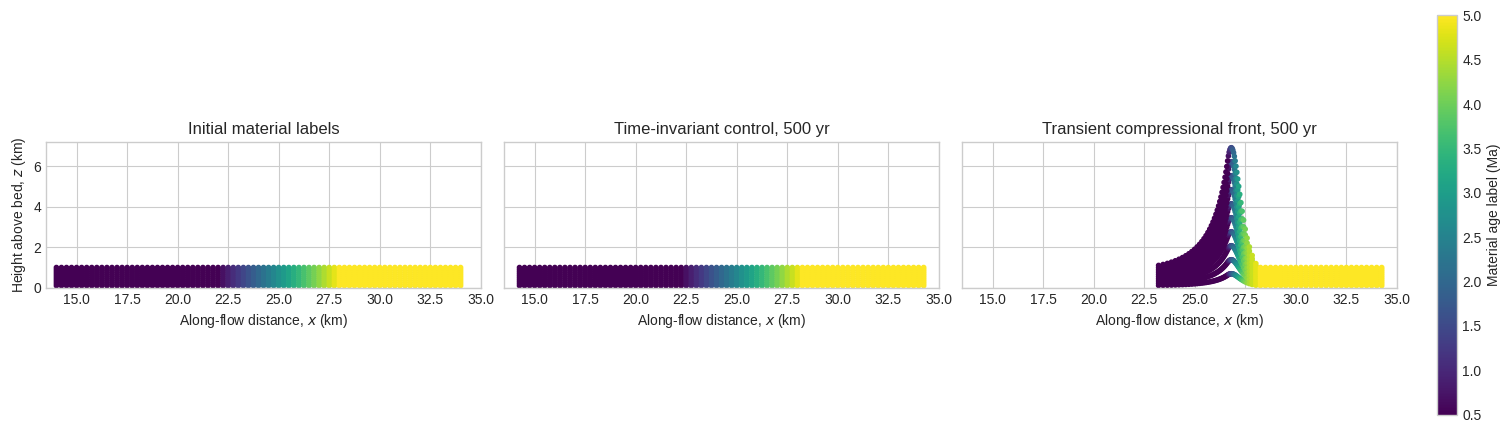

In [3]:
marker_x = np.linspace(14.0, 34.0, 81)
marker_z = np.linspace(0.1, 1.0, 10)
MX, MZ = np.meshgrid(marker_x, marker_z)
initial = np.column_stack((MX.ravel(), MZ.ravel()))
marker_shape = MX.shape
age_labels = np.interp(initial[:, 0], [X_YOUNG, X_OLD], [AGE_YOUNG, AGE_OLD])

coarse_model = build_model(80)
fine_model = build_model(160)
control, _ = advect(fine_model, initial, transient=False)
event_coarse, _ = advect(coarse_model, initial, transient=True)
event_fine, _ = advect(fine_model, initial, transient=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharex=True, sharey=True, constrained_layout=True)
states = [(initial, "Initial material labels"),
          (control, "Time-invariant control, 500 yr"),
          (event_fine, "Transient compressional front, 500 yr")]
for ax, (points, title) in zip(axes, states):
    grid = points.reshape(*marker_shape, 2)
    for row in grid:
        ax.plot(row[:, 0], row[:, 1], color="0.68", lw=0.6, zorder=1)
    scatter = ax.scatter(points[:, 0], points[:, 1], c=age_labels, s=9,
                         cmap="viridis", vmin=AGE_YOUNG, vmax=AGE_OLD, zorder=2)
    ax.set_title(title)
    ax.set_xlabel("Along-flow distance, $x$ (km)")
    ax.set_xlim(13.5, 35.0)
    ax.set_ylim(0.0, 7.2)
    ax.set_aspect("equal")
axes[0].set_ylabel("Height above bed, $z$ (km)")
cbar = fig.colorbar(scatter, ax=axes, shrink=0.78, pad=0.02)
cbar.set_label("Material age label (Ma)")
plt.show()

**Figure 1. Material response to steady and transient flow.** The steady control translates the labels without deforming them. The transient pulse shortens the lateral age transition and rotates the initially horizontal marker layers upward. Intermediate-age material remains between the selected young and old columns; it is stretched vertically rather than removed. This lateral view is not itself evidence for the observed vertical age reversal. The several-kilometer modeled thickening is a warning that this strong smooth-flow event is not a plausible reconstruction of present Allan Hills geometry.

In [4]:
def gridded_area(points, shape):
    """Sum quadrilateral marker-cell areas as a mass proxy for unit density."""
    grid = points.reshape(*shape, 2)
    total = 0.0
    for j in range(shape[0] - 1):
        for i in range(shape[1] - 1):
            quad = np.array([grid[j, i], grid[j, i + 1],
                             grid[j + 1, i + 1], grid[j + 1, i]])
            xq, zq = quad[:, 0], quad[:, 1]
            total += 0.5 * abs(np.dot(xq, np.roll(zq, -1))
                               - np.dot(zq, np.roll(xq, -1)))
    return total

def diagnostics(model, final, transient=True):
    young_index = np.argmin((initial[:, 0] - X_YOUNG) ** 2 + (initial[:, 1] - 0.5) ** 2)
    old_index = np.argmin((initial[:, 0] - X_OLD) ** 2 + (initial[:, 1] - 0.5) ** 2)
    initial_separation = initial[old_index, 0] - initial[young_index, 0]
    final_separation = final[old_index, 0] - final[young_index, 0]
    area_0 = gridded_area(initial, marker_shape)
    area_f = gridded_area(final, marker_shape)
    return {
        "dx": L_X / model["nx"],
        "separation": final_separation,
        "shortening": 100.0 * (1.0 - final_separation / initial_separation),
        "young_displacement": final[young_index, 0] - initial[young_index, 0],
        "vertical_stretch": final[young_index, 1] / initial[young_index, 1],
        "mass_error": 100.0 * (area_f - area_0) / area_0,
        "div_ratio": 100.0 * model["div_ratio"] if transient else 0.0,
    }

coarse = diagnostics(coarse_model, event_coarse)
fine = diagnostics(fine_model, event_fine)
steady = diagnostics(fine_model, control, transient=False)

print("case       dx (km)  final gap (km)  shortening (%)  young dx (km)  z stretch  mass error (%)  div/grad (%)")
for name, values in [("steady", steady), ("coarse", coarse), ("fine", fine)]:
    print(f"{name:8s} {values['dx']:8.3f} {values['separation']:15.4f}"
          f" {values['shortening']:15.2f} {values['young_displacement']:14.3f}"
          f" {values['vertical_stretch']:10.2f} {values['mass_error']:15.4f}"
          f" {values['div_ratio']:12.4f}")
print(f"\nFactor-of-two resolution change in final gap: "
      f"{100 * abs(coarse['separation'] - fine['separation']) / fine['separation']:.3f}%")

case       dx (km)  final gap (km)  shortening (%)  young dx (km)  z stretch  mass error (%)  div/grad (%)
steady      0.250          6.0000            0.00          0.250       1.00          0.0000       0.0000
coarse      0.500          1.6239           72.94          4.626       6.22         -0.2183       0.1563
fine        0.250          1.6256           72.91          4.624       6.27          0.0151       0.0394

Factor-of-two resolution change in final gap: 0.106%


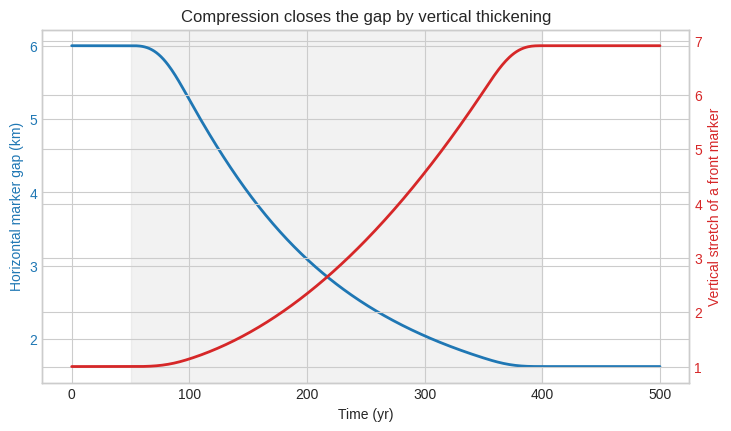

In [5]:
probe_initial = np.array([[X_YOUNG, 0.5], [X_OLD, 0.5], [23.0, 1.0]])
_, probe_history = advect(fine_model, probe_initial, transient=True, keep_history=True)
times = np.arange(probe_history.shape[0]) * DT
gap_history = probe_history[:, 1, 0] - probe_history[:, 0, 0]
stretch_history = probe_history[:, 2, 1] / probe_initial[2, 1]

fig, ax1 = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
ax1.plot(times, gap_history, color="tab:blue", lw=2, label="young-old marker gap")
ax1.set_xlabel("Time (yr)")
ax1.set_ylabel("Horizontal marker gap (km)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2 = ax1.twinx()
ax2.plot(times, stretch_history, color="tab:red", lw=2, label="vertical stretch")
ax2.set_ylabel("Vertical stretch of a front marker", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.axvspan(50, 400, color="0.8", alpha=0.25, label="velocity-pulse interval")
ax1.set_title("Compression closes the gap by vertical thickening")
plt.show()

**Figure 2. Collision kinematics.** The gap closes only while the pulse is active. Incompressibility links horizontal shortening to vertical stretching, so the same deformation that narrows the age transition thickens and rotates the material layers.

## Vertical-order test

The final marker grid is triangulated using its material connectivity. Synthetic cores are then sampled at 321 uniformly spaced candidate $x$ positions spanning the deformed material domain. A core passes if it contains a Pleistocene label ($A\leq1$ Ma) with approximately 5 Ma ice above ($A\geq4$ Ma) and ice at least 0.05 Ma older below. The 0.05 Ma tolerance only separates a genuine reversal from interpolation noise; the conclusion is unchanged for any positive tolerance because the modeled vertical profiles are uniform to numerical precision.

The representative synthetic core is selected objectively. Among all cores containing Pleistocene ice, it maximizes the smaller of the upper and lower age contrasts; ties are resolved by taking the candidate nearest the median Pleistocene-bearing position.

Vertical-order scan: 0 of 321 candidate cores pass; 102 contain Pleistocene ice.
Passing x positions (km): none
Maximum vertical age range over all cores: 8.527e-14 Ma
Selected objective core: x = 24.948 km, age range = 0.000e+00 Ma
Overturned layer segments: 0 of 800; maximum |angle| = 82.46 degrees.
Minimum horizontal stretch = 0.1441; maximum marker vertical stretch = 6.93.


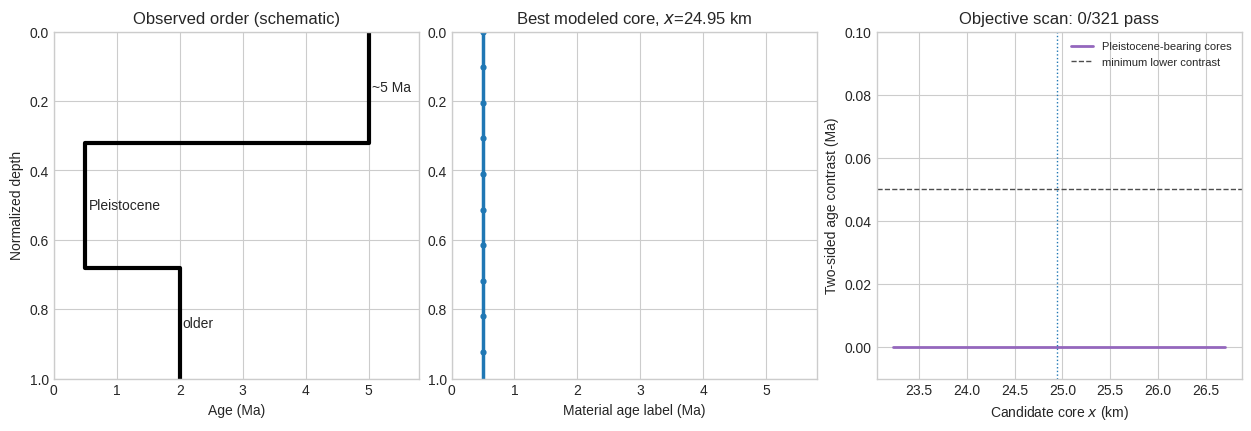

In [6]:
grid_rows, grid_cols = marker_shape
triangles = []
for j in range(grid_rows - 1):
    for i in range(grid_cols - 1):
        lower_left = j * grid_cols + i
        lower_right = lower_left + 1
        upper_left = (j + 1) * grid_cols + i
        upper_right = upper_left + 1
        triangles.extend(((lower_left, lower_right, upper_right),
                          (lower_left, upper_right, upper_left)))
triangulation = mtri.Triangulation(
    event_fine[:, 0], event_fine[:, 1], np.asarray(triangles),
)
age_interpolator = mtri.LinearTriInterpolator(triangulation, age_labels)

x_candidates = np.linspace(event_fine[:, 0].min() + 0.02,
                           event_fine[:, 0].max() - 0.02, 321)
z_samples = np.linspace(event_fine[:, 1].min(), event_fine[:, 1].max(), 801)
pleistocene_max, upper_old_min, age_tolerance = 1.0, 4.0, 0.05
profiles = {}
has_pleistocene = np.zeros(x_candidates.size, dtype=bool)
passes_order = np.zeros(x_candidates.size, dtype=bool)
bracket_contrast = np.full(x_candidates.size, np.nan)
vertical_age_range = np.full(x_candidates.size, np.nan)

for core_index, core_x in enumerate(x_candidates):
    sampled = np.ma.asarray(age_interpolator(np.full_like(z_samples, core_x), z_samples))
    valid = ~np.ma.getmaskarray(sampled) & np.isfinite(sampled.filled(np.nan))
    if valid.sum() < 20:
        continue
    core_z = z_samples[valid]
    core_age = np.asarray(sampled[valid])
    order = np.argsort(core_z)[::-1]  # top to bottom
    core_z, core_age = core_z[order], core_age[order]
    profiles[core_index] = (core_z, core_age)
    vertical_age_range[core_index] = np.ptp(core_age)
    young_indices = np.flatnonzero(core_age <= pleistocene_max)
    has_pleistocene[core_index] = young_indices.size > 0
    local_contrasts = []
    for young_index in young_indices:
        ages_above = core_age[:young_index]
        ages_below = core_age[young_index + 1:]
        if not ages_above.size or not ages_below.size:
            continue
        young_age = core_age[young_index]
        local_contrasts.append(min(ages_above.max() - young_age,
                                   ages_below.max() - young_age))
        passes_order[core_index] |= (
            ages_above.max() >= upper_old_min
            and ages_below.max() >= young_age + age_tolerance
        )
    if local_contrasts:
        bracket_contrast[core_index] = max(local_contrasts)

admissible = np.flatnonzero(np.isfinite(vertical_age_range))
young_cores = np.flatnonzero(has_pleistocene & np.isfinite(bracket_contrast))
if not young_cores.size:
    raise RuntimeError("No candidate core contains the Pleistocene packet")
best_contrast = np.nanmax(bracket_contrast[young_cores])
ties = young_cores[np.isclose(bracket_contrast[young_cores], best_contrast, atol=1e-8)]
median_young_x = np.median(x_candidates[young_cores])
selected_index = ties[np.argmin(abs(x_candidates[ties] - median_young_x))]
selected_z, selected_age = profiles[selected_index]
selected_depth = (selected_z.max() - selected_z) / np.ptp(selected_z)

initial_grid = initial.reshape(*marker_shape, 2)
final_grid = event_fine.reshape(*marker_shape, 2)
initial_dx = np.diff(initial_grid[:, :, 0], axis=1)
final_dx = np.diff(final_grid[:, :, 0], axis=1)
final_dz = np.diff(final_grid[:, :, 1], axis=1)
segment_angle = np.degrees(np.arctan2(final_dz, final_dx))
overturned_segments = final_dx <= 0.0
horizontal_stretch = final_dx / initial_dx
marker_vertical_stretch = final_grid[:, :, 1] / initial_grid[:, :, 1]

print(f"Vertical-order scan: {passes_order[admissible].sum()} of "
      f"{admissible.size} candidate cores pass; "
      f"{has_pleistocene[admissible].sum()} contain Pleistocene ice.")
print(f"Passing x positions (km): "
      f"{x_candidates[passes_order].round(3).tolist() if passes_order.any() else 'none'}")
print(f"Maximum vertical age range over all cores: "
      f"{np.nanmax(vertical_age_range):.3e} Ma")
print(f"Selected objective core: x = {x_candidates[selected_index]:.3f} km, "
      f"age range = {np.ptp(selected_age):.3e} Ma")
print(f"Overturned layer segments: {overturned_segments.sum()} of "
      f"{overturned_segments.size}; maximum |angle| = "
      f"{np.max(abs(segment_angle)):.2f} degrees.")
print(f"Minimum horizontal stretch = {horizontal_stretch.min():.4f}; "
      f"maximum marker vertical stretch = {marker_vertical_stretch.max():.2f}.")

fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.2), constrained_layout=True)
target_depth = np.array([0.0, 0.32, 0.32, 0.68, 0.68, 1.0])
target_age = np.array([5.0, 5.0, 0.5, 0.5, 2.0, 2.0])
axes[0].plot(target_age, target_depth, lw=3, color="black")
axes[0].text(5.05, 0.16, "~5 Ma", va="center")
axes[0].text(0.55, 0.50, "Pleistocene", va="center")
axes[0].text(2.05, 0.84, "older", va="center")
axes[0].set_title("Observed order (schematic)")
axes[0].set_xlabel("Age (Ma)")
axes[0].set_ylabel("Normalized depth")
axes[0].set_ylim(1.0, 0.0)
axes[0].set_xlim(0.0, 5.8)

axes[1].plot(selected_age, selected_depth, lw=2.5, color="tab:blue")
axes[1].scatter(selected_age[::20], selected_depth[::20], s=12, color="tab:blue")
axes[1].set_title(f"Best modeled core, $x$={x_candidates[selected_index]:.2f} km")
axes[1].set_xlabel("Material age label (Ma)")
axes[1].set_ylim(1.0, 0.0)
axes[1].set_xlim(0.0, 5.8)

axes[2].plot(x_candidates[young_cores], bracket_contrast[young_cores],
             lw=2, color="tab:purple", label="Pleistocene-bearing cores")
axes[2].axhline(age_tolerance, color="0.3", ls="--", lw=1,
                label="minimum lower contrast")
axes[2].axvline(x_candidates[selected_index], color="tab:blue", ls=":", lw=1)
if passes_order.any():
    axes[2].scatter(x_candidates[passes_order], bracket_contrast[passes_order],
                    color="tab:green", label="passing cores")
axes[2].set_title(f"Objective scan: {passes_order[admissible].sum()}/{admissible.size} pass")
axes[2].set_xlabel("Candidate core $x$ (km)")
axes[2].set_ylabel("Two-sided age contrast (Ma)")
axes[2].set_ylim(-0.01, max(0.10, np.nanmax(bracket_contrast) * 1.1))
axes[2].legend(fontsize=8, loc="upper right")
plt.show()

**Figure 3. Vertical-order test.** The left panel shows the required top-to-bottom old–Pleistocene–older sequence. The middle panel shows the best Pleistocene-bearing synthetic core chosen by the objective scan. The right panel reports the two-sided age contrast for every Pleistocene-bearing candidate; a passing core must also contain an upper age of at least 4 Ma. No candidate passes.

## Interpretation

The collision pulse displaces the leading young marker by several kilometers and shortens the selected 6 km interval. However, it creates lateral juxtaposition and vertical thickening, not the observed vertical age reversal. Every final vertical core is effectively single-age, all material-layer segments retain positive $\mathrm{d}x$, and no segment passes through vertical. The finite strain is large, but it remains orientation preserving.

This behavior separates the two stages described by [Waddington, Bolzan, and Alley (2001)](https://doi.org/10.3189/172756501781831756). Spatial gradients in vertical velocity bend the initially horizontal marker rows and can be viewed as a seed disturbance. Nevertheless, the modeled horizontal velocity has no vertical shear, $\partial u/\partial z=0$, and the post-event background flow has no velocity gradient. The collision therefore lacks the subsequent shear-driven rotation that could carry a seeded limb through vertical. Its compressional pure strain steepens and vertically extends the disturbance during the pulse; in the large-scale extensional setting considered by Waddington and colleagues, pure shear instead flattens a wrinkle. Neither case supplies overturning here.

The factor-of-two mesh comparison and marker-cell area establish that the broad lateral transition and large thickening are not resolution or mass-balance artifacts. They do not establish that a 30 m/yr pulse occurred at Allan Hills. The toy model also cannot predict the pulse from rheology, represent a thrust or fracture, resolve three-dimensional bypass, create the initial 5 Ma reservoir, or evaluate isotope diffusion. A viable collision model requires a fault-like discontinuity or a later vertically sheared flow that demonstrably overturns a seeded layer.